# Old ConSim vs New ConSim comparison

Loads scores from `data/consim_{model}.csv`, restricts to keys that exist for both
`old_consim` and `new_consim` (same dataset / classes_subset / seed / method /
nb_concepts / interpretation / prompt_type), and plots the per-prompt-type score
difference `new_consim - old_consim` as a bar plot, sorted in decreasing order.

Error bars: for each prompt_type we have 50 seeds. Seeds are grouped into
5 buckets of 10 (by seed index, so seeds 0-9, 10-19, ...). The per-bucket
difference is the difference of bucket means (`mean(new) - mean(old)` over 10
seeds). The plotted bar is the mean of the 5 bucket-differences and the
error bar is their standard deviation.

## Parameters

In [1]:
# ---------------------------------------------------------------------------
# Filters. Set to None to include all, or to a list/set of values to subset.
# Values are matched exactly against the corresponding CSV column.
# ---------------------------------------------------------------------------

# Judge model -> picks the score CSV `data/consim_{MODEL_FILE}.csv`.
# Example: "meta-llama_Llama-3.2-3B-Instruct".
MODEL_FILE = "meta-llama_Llama-3.2-3B-Instruct"

# Subset filters (None = keep all values present in the CSV).
DATASETS = None          # e.g. ["RT", "BIOS"]
PROMPT_TYPES = None      # e.g. ["AC1", "AC2", "AB1"]
CLASSES_SUBSETS = None   # e.g. ["[0, 1]"] (string form, exactly as in the CSV)

# Bucketing for the std estimate.
SEEDS_PER_BUCKET = 10    # 50 seeds -> 5 buckets of 10
EXPECTED_SEEDS = 50      # used only for a warning if a key has != this many seeds

## Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path(".").resolve().parent
CSV_PATH = REPO_ROOT / "data" / f"consim_{MODEL_FILE}.csv"
assert CSV_PATH.exists(), f"Score CSV not found: {CSV_PATH}"

## Load and filter scores

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH.name}")
print(f"  specifications: {sorted(df['specification'].unique())}")
print(f"  datasets:       {sorted(df['dataset'].unique())}")
print(f"  prompt_types:   {sorted(df['prompt_type'].unique())}")
print(f"  classes_subsets:{sorted(df['classes_subset'].unique())}")
print(f"  methods:        {sorted(df['method'].unique())}")
df.head()

Loaded 7600 rows from consim_meta-llama_Llama-3.2-3B-Instruct.csv
  specifications: ['new_consim', 'old_consim']
  datasets:       ['AG', 'E', 'IMDB', 'RT']
  prompt_types:   ['AB1', 'AB2', 'AC1', 'AC2', 'AC3', 'B1', 'B2', 'C1', 'C2', 'C3']
  classes_subsets:['[0, 1, 2, 3, 4, 5]', '[0, 1, 2, 3]', '[0, 1]']
  methods:        ['BatchTopKSAE', 'ICA', 'PCA', 'SVD', 'SemiNMF', 'VanillaSAE', 'baseline']


,dataset,model,classes_subset,seed,method,nb_concepts,interpretation,prompt_type,specification,time,score
0,RT,RB,"[0, 1]",0,SemiNMF,6,topk,AC3,new_consim,2026-06-17 18:17:12.332284,1.0
1,RT,RB,"[0, 1]",0,SemiNMF,6,topk,C3,new_consim,2026-06-17 18:17:13.488787,1.0
2,RT,RB,"[0, 1]",0,SemiNMF,6,topk,AC1,new_consim,2026-06-17 18:17:15.440580,1.0
3,RT,RB,"[0, 1]",0,SemiNMF,6,topk,C1,new_consim,2026-06-17 18:17:16.662556,1.0
4,RT,RB,"[0, 1]",0,baseline,6,topk,AB2,new_consim,2026-06-17 18:17:18.822435,1.0


In [4]:
# Apply the optional subset filters. None -> keep all.
def _apply_filter(frame: pd.DataFrame, column: str, values) -> pd.DataFrame:
    if values is None:
        return frame
    values = list(values)
    out = frame[frame[column].isin(values)]
    missing = set(values) - set(frame[column].unique())
    if missing:
        print(f"  warning: {column} values not in CSV: {sorted(missing)}")
    return out


df_f = df.copy()
df_f = _apply_filter(df_f, "dataset", DATASETS)
df_f = _apply_filter(df_f, "prompt_type", PROMPT_TYPES)
df_f = _apply_filter(df_f, "classes_subset", CLASSES_SUBSETS)

# Keep only the two specifications we compare.
df_f = df_f[df_f["specification"].isin(["old_consim", "new_consim"])]

print(f"After filtering: {len(df_f)} rows")
print(f"  old_consim rows: {(df_f['specification'] == 'old_consim').sum()}")
print(f"  new_consim rows: {(df_f['specification'] == 'new_consim').sum()}")

After filtering: 7600 rows
  old_consim rows: 500
  new_consim rows: 7100


## Restrict to keys present in both old_consim and new_consim

A "key" is everything that identifies a single evaluated configuration:
`(dataset, model, classes_subset, seed, method, nb_concepts, interpretation, prompt_type)`.
Only keys that appear under both specifications are kept.

In [5]:
KEY_COLS = [
    "dataset",
    "model",
    "classes_subset",
    "seed",
    "method",
    "nb_concepts",
    "interpretation",
    "prompt_type",
]

# Average duplicates (same key + same specification appearing multiple times,
# e.g. after a rescore). This makes the join deterministic.
df_agg = (
    df_f.groupby(KEY_COLS + ["specification"], dropna=False)["score"]
    .mean()
    .reset_index()
)

# Pivot so each key has both specification scores side by side; inner join on key.
df_wide = df_agg.pivot_table(
    index=KEY_COLS,
    columns="specification",
    values="score",
    aggfunc="mean",
).dropna(subset=["old_consim", "new_consim"]).reset_index()

df_wide["diff"] = df_wide["new_consim"] - df_wide["old_consim"]

print(f"Common keys (rows with both specs): {len(df_wide)}")
df_wide.head()

Common keys (rows with both specs): 500


specification,dataset,model,classes_subset,seed,method,nb_concepts,interpretation,prompt_type,new_consim,old_consim,diff
0,RT,RB,"[0, 1]",0,SemiNMF,6,topk,AC1,1.0,0.0,1.0
1,RT,RB,"[0, 1]",0,SemiNMF,6,topk,AC2,1.0,0.4,0.6
2,RT,RB,"[0, 1]",0,SemiNMF,6,topk,AC3,1.0,0.0,1.0
3,RT,RB,"[0, 1]",0,SemiNMF,6,topk,C1,1.0,0.0,1.0
4,RT,RB,"[0, 1]",0,SemiNMF,6,topk,C2,1.0,0.0,1.0


## Aggregate per prompt_type: mean and std across 5 buckets of 10 seeds

In [6]:
def _bucket_stats(group: pd.DataFrame) -> pd.Series:
    """Return mean and std of the per-bucket new-old difference.

    A bucket is a contiguous block of `SEEDS_PER_BUCKET` distinct seeds (ordered
    by seed value). Within a bucket we compute the mean of `new_consim`, the
    mean of `old_consim`, and take their difference. We then return the mean
    and std of those bucket-differences. A bucket that ends up partial (fewer
    than `SEEDS_PER_BUCKET` seeds available) is dropped so the std is only
    computed across full buckets.
    """
    g = group.sort_values("seed")
    seeds = g["seed"].to_numpy()
    n_seeds = len(seeds)
    if n_seeds != EXPECTED_SEEDS:
        # Warn but still compute over whatever full buckets are available.
        print(
            f"  warning: prompt_type={group.name!r} has {n_seeds} seeds "
            f"(expected {EXPECTED_SEEDS})"
        )
    n_buckets = n_seeds // SEEDS_PER_BUCKET
    if n_buckets == 0:
        return pd.Series({"mean_diff": np.nan, "std_diff": np.nan, "n_buckets": 0, "n_seeds": n_seeds})
    new_vals = g["new_consim"].to_numpy()[: n_buckets * SEEDS_PER_BUCKET]
    old_vals = g["old_consim"].to_numpy()[: n_buckets * SEEDS_PER_BUCKET]
    new_buckets = new_vals.reshape(n_buckets, SEEDS_PER_BUCKET).mean(axis=1)
    old_buckets = old_vals.reshape(n_buckets, SEEDS_PER_BUCKET).mean(axis=1)
    diff_buckets = new_buckets - old_buckets
    return pd.Series(
        {
            "mean_diff": float(diff_buckets.mean()),
            # ddof=1 (sample std) to be conservative with only 5 buckets.
            "std_diff": float(diff_buckets.std(ddof=1)) if n_buckets > 1 else 0.0,
            "n_buckets": int(n_buckets),
            "n_seeds": int(n_seeds),
        }
    )


# Group by prompt_type only; everything else (dataset, classes_subset, method, ...)
# is pooled across whatever is left after filtering.
stats = (
    df_wide.groupby("prompt_type", dropna=False)
    .apply(_bucket_stats, include_groups=False)
    .reset_index()
    .sort_values("mean_diff", ascending=False)
    .reset_index(drop=True)
)
stats

,prompt_type,mean_diff,std_diff,n_buckets,n_seeds
0,C1,0.948,0.054037,5.0,50.0
1,AC1,0.928,0.050200,5.0,50.0
2,AC3,0.916,0.063875,5.0,50.0
3,AC2,0.916,0.038471,5.0,50.0
4,C2,0.884,0.066933,5.0,50.0
5,C3,0.852,0.048166,5.0,50.0
6,AB2,0.692,0.055857,5.0,50.0
7,B2,0.688,0.060992,5.0,50.0
8,AB1,0.680,0.024495,5.0,50.0
9,B1,0.616,0.047749,5.0,50.0


## Bar plot of the per-prompt-type difference (new_consim - old_consim)

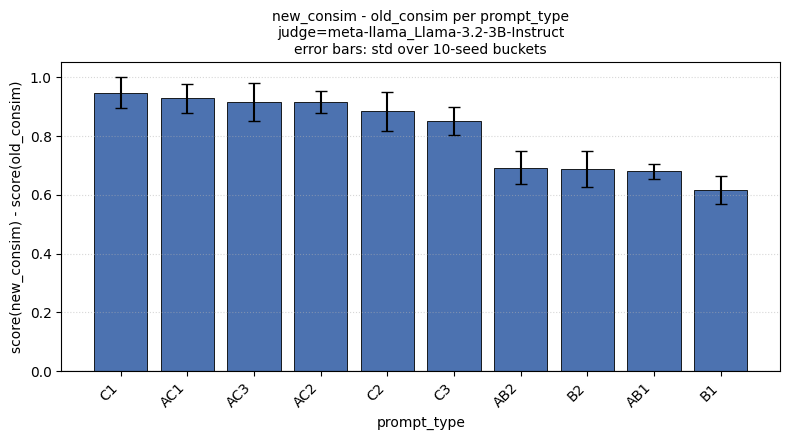

In [7]:
fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(stats) + 2), 4.5))

x = np.arange(len(stats))
colors = ["#4c72b0" if v >= 0 else "#c44e52" for v in stats["mean_diff"]]

ax.bar(
    x,
    stats["mean_diff"],
    yerr=stats["std_diff"],
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.6,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stats["prompt_type"], rotation=45, ha="right")
ax.set_ylabel("score(new_consim) - score(old_consim)")
ax.set_xlabel("prompt_type")

title_bits = [f"judge={MODEL_FILE}"]
if DATASETS is not None:
    title_bits.append(f"datasets={DATASETS}")
if CLASSES_SUBSETS is not None:
    title_bits.append(f"classes_subsets={CLASSES_SUBSETS}")
if PROMPT_TYPES is not None:
    title_bits.append(f"prompt_types={PROMPT_TYPES}")
ax.set_title(
    "new_consim - old_consim per prompt_type\n"
    + " | ".join(title_bits)
    + f"\nerror bars: std over {SEEDS_PER_BUCKET}-seed buckets",
    fontsize=10,
)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()